# Task
Train and evaluate a polynomial regression model to predict taxi trip pricing from the "taxi_trip_pricing.csv" dataset, comparing its performance against a linear regression baseline.

## **Import Libraries**

Import necessary libraries such as pandas, numpy, matplotlib, seaborn, sklearn for data manipulation, visualization, and model building.



Import the specified libraries: numpy, matplotlib.pyplot, seaborn, and specific modules from sklearn for data manipulation, visualization, and model building. Pandas is already imported.



In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## **Understand the Data**

Perform initial data exploration, including checking data types, missing values, descriptive statistics, and unique values for categorical columns.


To begin understanding the data, I will display the first few rows, check data types, identify missing values, and generate descriptive statistics for numerical columns. These steps provide a comprehensive overview of the dataset's structure and content.



In [2]:
df = pd.read_csv("taxi_trip_pricing.csv")

In [3]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


 Based on the previous output, the next logical step is to identify categorical columns and then display their unique values and counts to complete the data exploration as per the subtask instructions. Categorical columns include 'Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', and 'Weather'.


In [4]:
df.shape

(1000, 11)

In [5]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [7]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [8]:
df.nunique()

Trip_Distance_km         867
Time_of_Day                4
Day_of_Week                2
Passenger_Count            4
Traffic_Conditions         3
Weather                    3
Base_Fare                290
Per_Km_Rate              150
Per_Minute_Rate           41
Trip_Duration_Minutes    917
Trip_Price               951
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
df.isnull().sum()

Trip_Distance_km          0
Time_of_Day              50
Day_of_Week              50
Passenger_Count           0
Traffic_Conditions       50
Weather                  50
Base_Fare                 0
Per_Km_Rate               0
Per_Minute_Rate           0
Trip_Duration_Minutes     0
Trip_Price                0
dtype: int64

In [13]:
cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

df[cols] = df[cols].fillna(df[cols].mode().iloc[0])

In [14]:
df.isnull().sum()

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

## **Visualize the Data**

Create various plots to understand the distribution of features, identify relationships between variables, and visualize the target variable. Ensure all plots have legends.


The first instruction is to plot the distribution of the target variable 'Trip_Price' using a histogram from `seaborn`.



<Axes: ylabel='Count'>

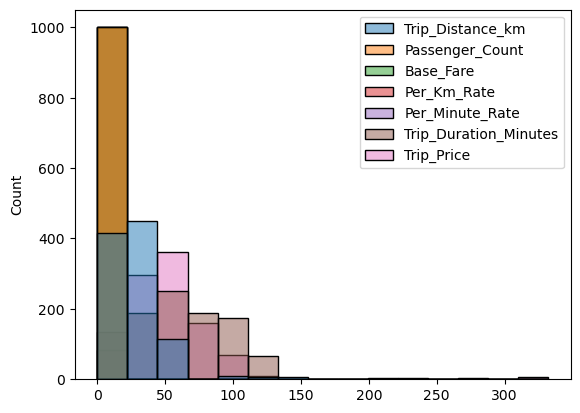

In [15]:
sns.histplot(df, bins=15)

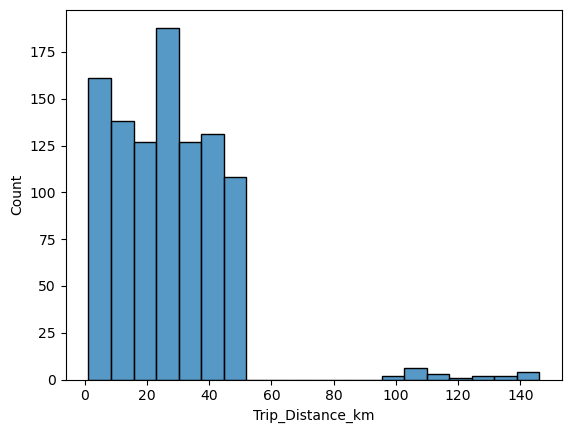

In [16]:
sns.histplot(df['Trip_Distance_km'], bins=20)
plt.show()

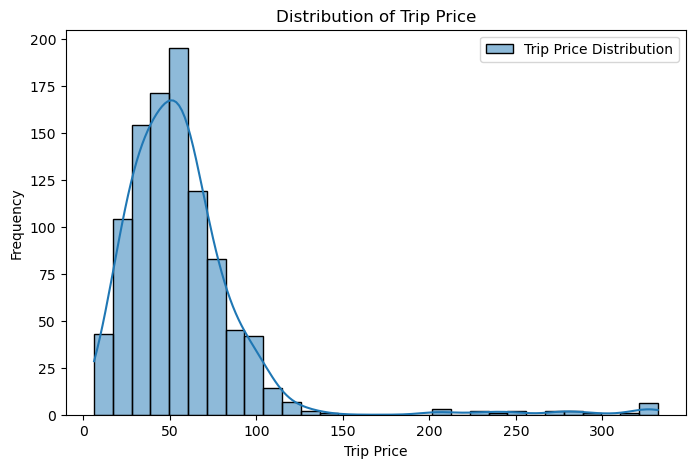

In [17]:
# Drop missing values for the target variable
trip_price = df['Trip_Price'].dropna()

plt.figure(figsize=(8, 5))
sns.histplot(trip_price, bins=30, kde=True, label='Trip Price Distribution')

plt.xlabel('Trip Price')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Price')
plt.legend()
plt.show()

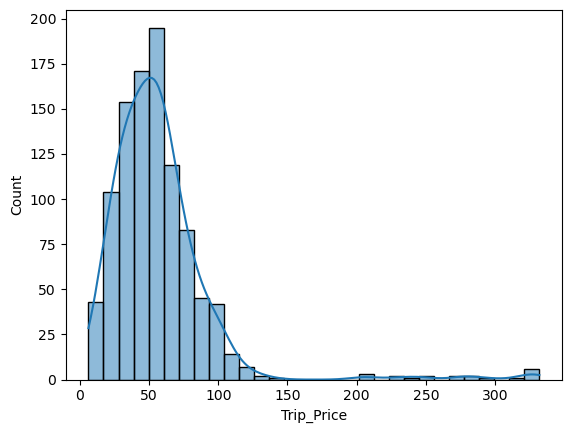

In [18]:
sns.histplot(df['Trip_Price'], bins=30, kde=True)
plt.show()

The next step is to create scatter plots to visualize the relationship between key numerical features ('Trip_Distance_km' and 'Trip_Duration_Minutes') and the 'Trip_Price'.



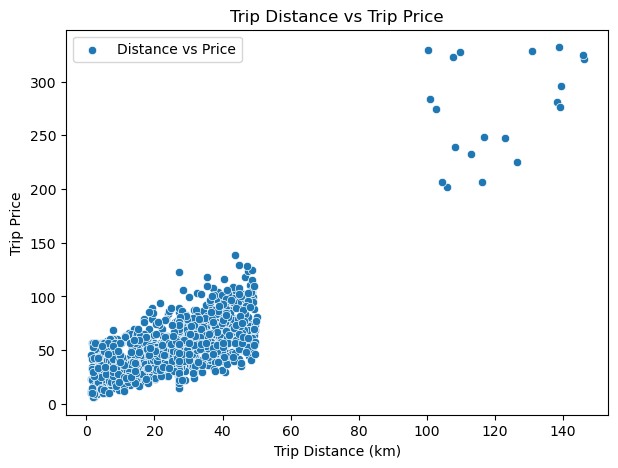

In [19]:
# Drop rows with missing values for plotting
distance_price_df = df[['Trip_Distance_km', 'Trip_Price']].dropna()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=distance_price_df,
    x='Trip_Distance_km',
    y='Trip_Price',
    label='Distance vs Price'
)

plt.xlabel('Trip Distance (km)')
plt.ylabel('Trip Price')
plt.title('Trip Distance vs Trip Price')
plt.legend()
plt.show()


<Axes: xlabel='Trip_Distance_km', ylabel='Trip_Price'>

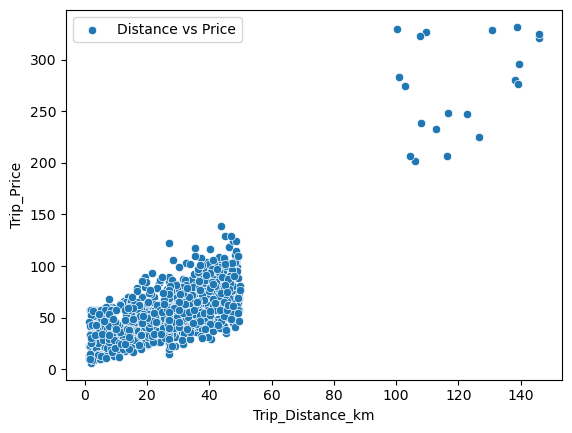

In [20]:
sns.scatterplot(
    data=df,
    x='Trip_Distance_km',
    y='Trip_Price',
    label='Distance vs Price'
)

The next step is to generate box plots to visualize the relationship between each categorical feature ('Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather') and the target variable 'Trip_Price'.



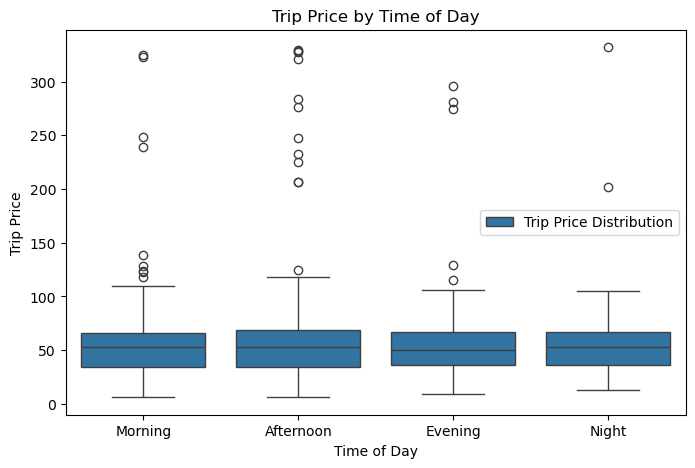

In [21]:
df_cat = df.dropna(subset=['Trip_Price'])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cat,
    x='Time_of_Day',
    y='Trip_Price'
)

plt.title('Trip Price by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Trip Price')
plt.legend(['Trip Price Distribution'])
plt.show()

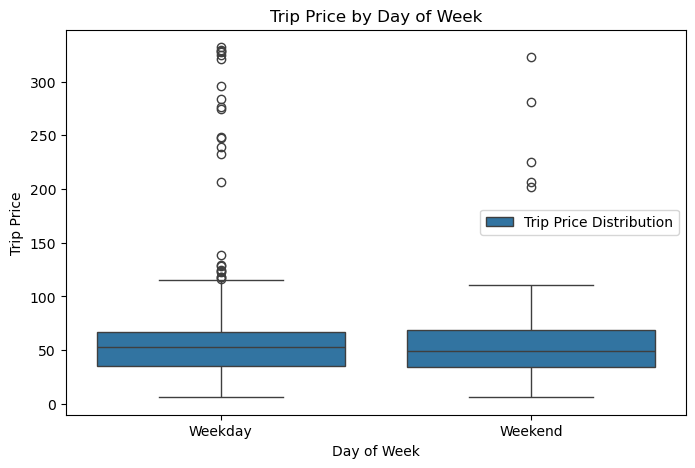

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cat,
    x='Day_of_Week',
    y='Trip_Price'
)

plt.title('Trip Price by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Trip Price')
plt.legend(['Trip Price Distribution'])
plt.show()

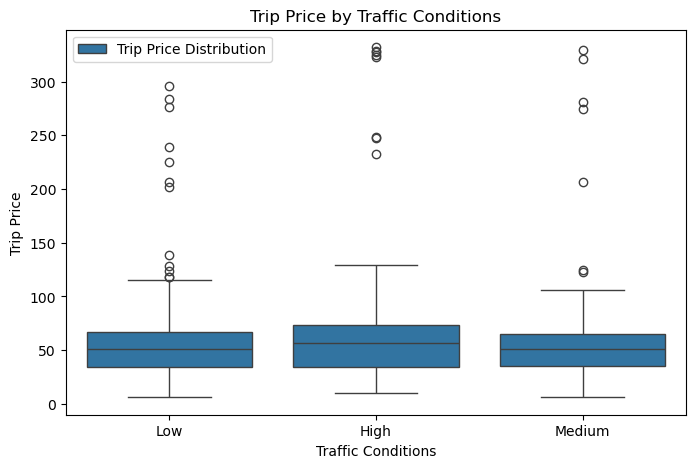

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cat,
    x='Traffic_Conditions',
    y='Trip_Price'
)

plt.title('Trip Price by Traffic Conditions')
plt.xlabel('Traffic Conditions')
plt.ylabel('Trip Price')
plt.legend(['Trip Price Distribution'])
plt.show()


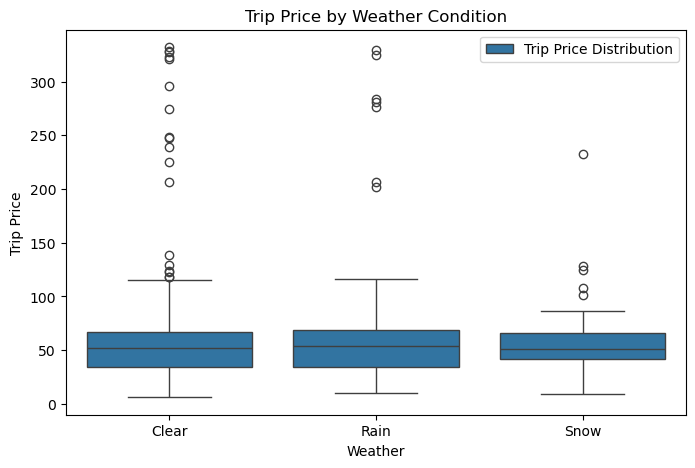

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_cat,
    x='Weather',
    y='Trip_Price'
)

plt.title('Trip Price by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Trip Price')
plt.legend(['Trip Price Distribution'])
plt.show()

In [25]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.80,0.32,53.82,36.262400
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.62,0.43,40.57,56.874773
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.21,0.15,37.27,52.903200
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.51,0.15,116.81,36.469800
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.63,0.32,22.64,15.618000


In [26]:
df.nunique()

Trip_Distance_km         868
Time_of_Day                4
Day_of_Week                2
Passenger_Count            5
Traffic_Conditions         3
Weather                    3
Base_Fare                291
Per_Km_Rate              151
Per_Minute_Rate           42
Trip_Duration_Minutes    918
Trip_Price               952
dtype: int64

## Now Label Encoding AND One-Hot Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Day_of_Week'] = le.fit_transform(df['Day_of_Week'])

In [28]:
df = pd.get_dummies(
    df,
    columns=['Time_of_Day', 'Traffic_Conditions', 'Weather'],
    drop_first=True,
    dtype=int
)

In [29]:
df.head()

,Trip_Distance_km,Day_of_Week,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.350000,0,3.0,3.560000,0.80,0.32,53.82,36.262400,0,1,0,1,0,0,0
1,47.590000,0,1.0,3.502989,0.62,0.43,40.57,56.874773,0,0,0,0,0,0,0
2,36.870000,1,1.0,2.700000,1.21,0.15,37.27,52.903200,1,0,0,0,0,0,0
3,30.330000,0,4.0,3.480000,0.51,0.15,116.81,36.469800,1,0,0,1,0,0,0
4,27.070547,0,3.0,2.930000,0.63,0.32,22.64,15.618000,1,0,0,0,0,0,0


## **Prepare Features (X & y)**

Separate the dataset into features (X) and the target variable (y). Handle categorical features using one-hot encoding, and split the data into training and testing sets.


In [30]:
X = df.drop('Trip_Price', axis=1)
Y = df['Trip_Price']

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( X, Y, test_size=0.2, random_state=42)



In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [33]:
from sklearn.linear_model import LinearRegression


In [34]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

In [35]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [36]:
poly_reg = LinearRegression()
poly_reg.fit(x_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
